# 📊 01 - Analyse Exploratoire des Données (EDA)

**Objectif:** Explorer le dataset Credit Card Fraud Detection pour comprendre la structure des données, identifier les patterns et préparer le preprocessing.

**Dataset:** [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


In [2]:
import sys
from pathlib import Path
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from src.preprocessing import load_raw_data

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def get_data_summary(df: pd.DataFrame) -> dict:
    """Retourne un résumé rapide du dataset pour l'EDA."""
    return {
        "shape": df.shape,
        "missing_values": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "columns": list(df.columns),
    }


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Chargement et aperçu du dataset


In [3]:
df = load_raw_data()
print(f"Shape: {df.shape}")
print(f"\nRésumé:")
summary = get_data_summary(df)
for k, v in summary.items():
    print(f"  {k}: {v}")

df.head()

2026-05-25 12:43:16.672 | INFO     | src.preprocessing:load_raw_data:29 - Dataset charge: (284807, 31)


Shape: (284807, 31)

Résumé:
  shape: (284807, 31)
  missing_values: 0
  duplicate_rows: 1081
  columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Types et info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
# Statistiques descriptives
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2. Analyse du déséquilibre des classes


Transactions légitimes: 284315 (99.827%)
Transactions frauduleuses: 492 (0.173%)

Ratio fraude/légitime: 1:577


C:\Users\Province Settat\AppData\Local\Temp\ipykernel_22452\4249349079.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Légitime', 'Fraude'], y=class_counts.values, ax=axes[0], palette=['#2ecc71', '#e74c3c'])


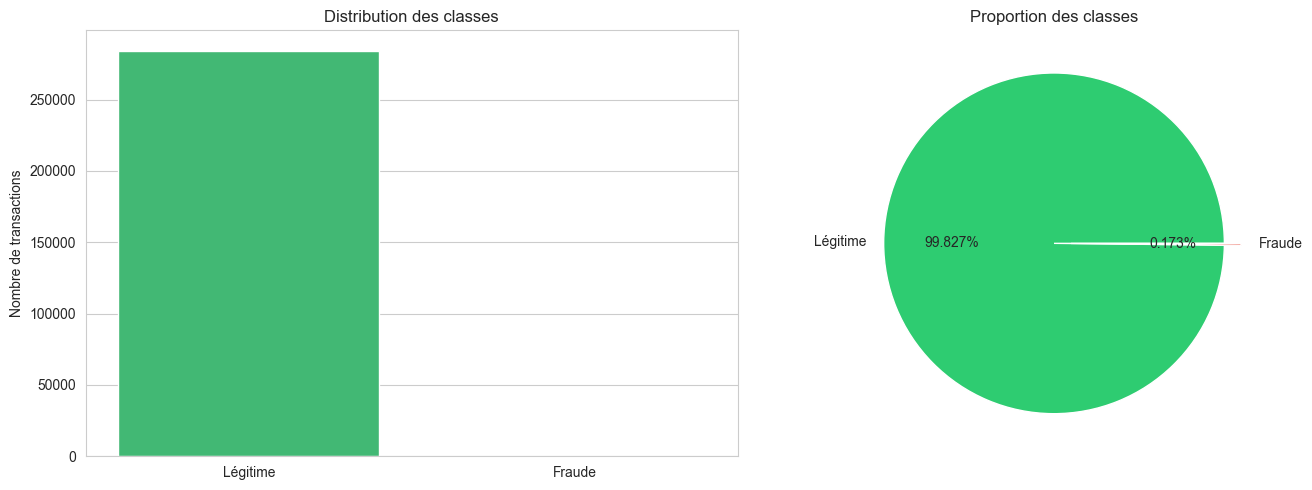

In [6]:
class_counts = df['Class'].value_counts()
print(f"Transactions légitimes: {class_counts[0]} ({class_counts[0]/len(df)*100:.3f}%)")
print(f"Transactions frauduleuses: {class_counts[1]} ({class_counts[1]/len(df)*100:.3f}%)")
print(f"\nRatio fraude/légitime: 1:{class_counts[0]//class_counts[1]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.barplot(x=['Légitime', 'Fraude'], y=class_counts.values, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre de transactions')

# Pie chart
axes[1].pie(class_counts.values, labels=['Légitime', 'Fraude'], autopct='%1.3f%%',
            colors=['#2ecc71', '#e74c3c'], explode=[0, 0.1])
axes[1].set_title('Proportion des classes')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Analyse des montants


C:\Users\Province Settat\AppData\Local\Temp\ipykernel_22452\3756421438.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Amount', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
C:\Users\Province Settat\AppData\Local\Temp\ipykernel_22452\3756421438.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Légitime', 'Fraude'])


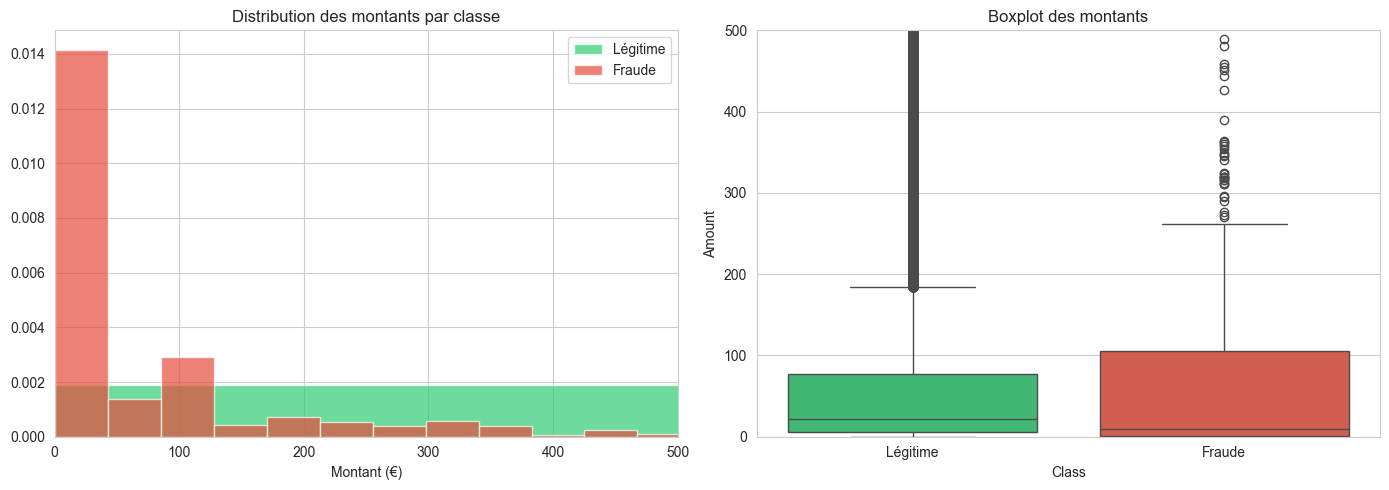


Montant moyen - Légitime: 88.29€
Montant moyen - Fraude: 122.21€


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des montants par classe
for cls, color, label in [(0, '#2ecc71', 'Légitime'), (1, '#e74c3c', 'Fraude')]:
    subset = df[df['Class'] == cls]['Amount']
    axes[0].hist(subset, bins=50, alpha=0.7, color=color, label=label, density=True)
axes[0].set_title('Distribution des montants par classe')
axes[0].set_xlabel('Montant (€)')
axes[0].legend()
axes[0].set_xlim(0, 500)

# Boxplot
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Boxplot des montants')
axes[1].set_ylim(0, 500)
axes[1].set_xticklabels(['Légitime', 'Fraude'])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMontant moyen - Légitime: {df[df['Class']==0]['Amount'].mean():.2f}€")
print(f"Montant moyen - Fraude: {df[df['Class']==1]['Amount'].mean():.2f}€")

## 4. Analyse temporelle


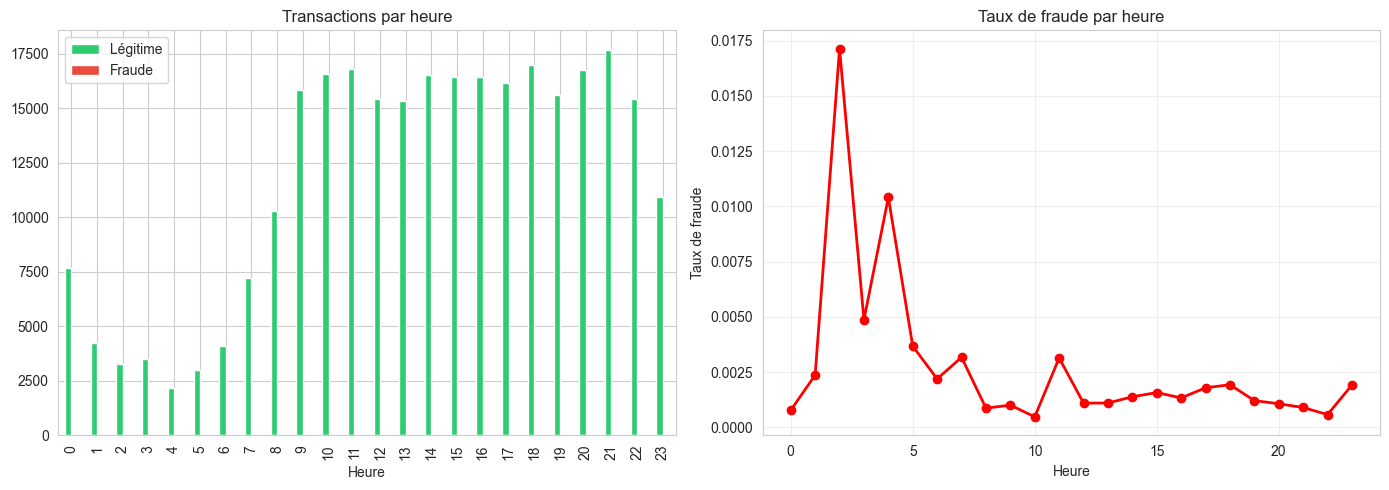

In [8]:
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transactions par heure
df.groupby(['Hour', 'Class']).size().unstack().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transactions par heure')
axes[0].set_xlabel('Heure')
axes[0].legend(['Légitime', 'Fraude'])

# Taux de fraude par heure
fraud_rate = df.groupby('Hour')['Class'].mean()
axes[1].plot(fraud_rate.index, fraud_rate.values, 'r-o', linewidth=2)
axes[1].set_title('Taux de fraude par heure')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Taux de fraude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Corrélations


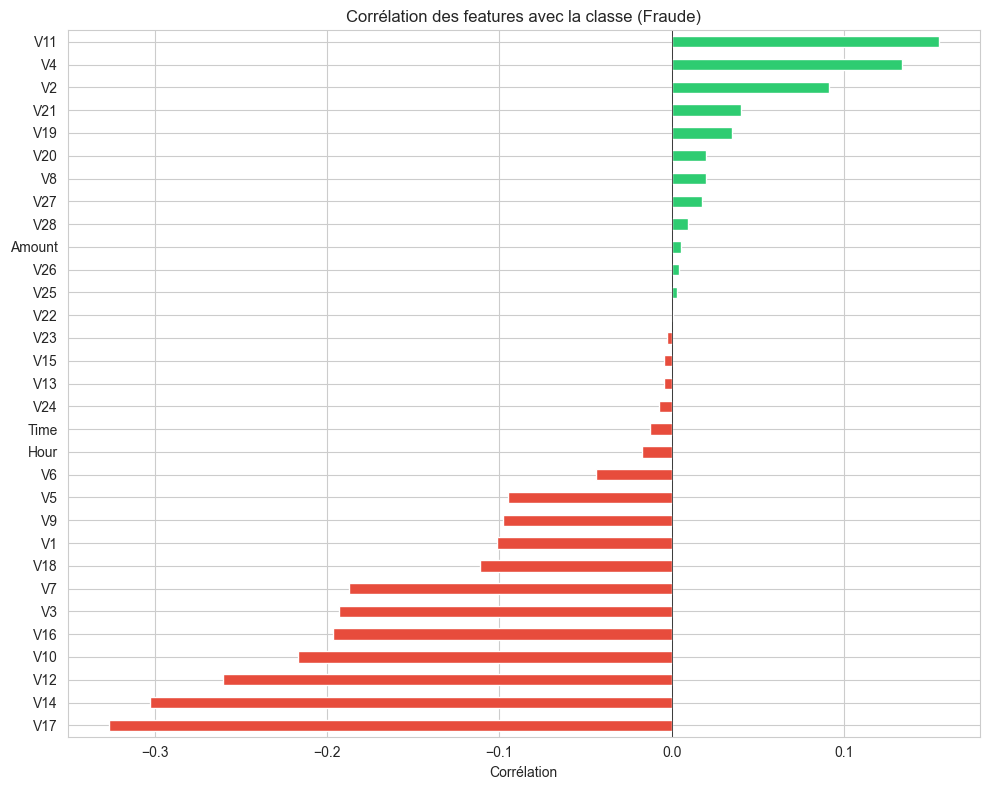


Top 5 corrélations positives:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Top 5 corrélations négatives:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [9]:
# Corrélation avec la variable cible
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Corrélation des features avec la classe (Fraude)')
ax.set_xlabel('Corrélation')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 corrélations positives:")
print(correlations.tail(5))
print("\nTop 5 corrélations négatives:")
print(correlations.head(5))

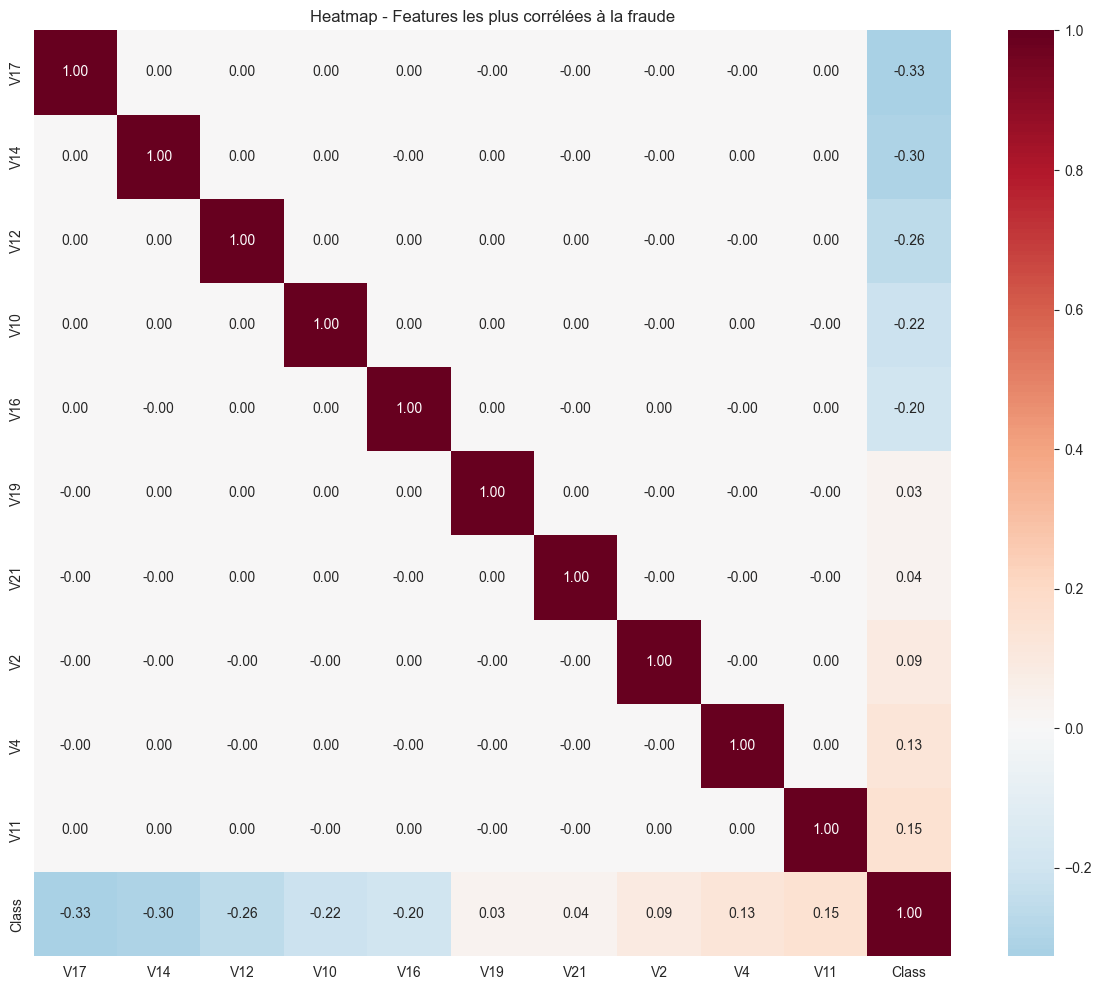

In [10]:
# Heatmap des features les plus corrélées
top_features = list(correlations.head(5).index) + list(correlations.tail(5).index) + ['Class']
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, cmap='RdBu_r', center=0, ax=ax, fmt='.2f')
ax.set_title('Heatmap - Features les plus corrélées à la fraude')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Valeurs manquantes et doublons


In [11]:
print(f"Valeurs manquantes: {df.isnull().sum().sum()}")
print(f"Doublons: {df.duplicated().sum()}")
print(f"\n✅ Dataset propre - pas de valeurs manquantes")
if df.duplicated().sum() > 0:
    print(f"⚠️ {df.duplicated().sum()} doublons à supprimer lors du preprocessing")

Valeurs manquantes: 0
Doublons: 1081

✅ Dataset propre - pas de valeurs manquantes
⚠️ 1081 doublons à supprimer lors du preprocessing


## 7. Conclusions EDA

**Observations clés:**

1. **Déséquilibre extrême:** ~0.17% de fraudes → nécessite SMOTE ou class weights
2. **Features PCA:** V1-V28 déjà transformées, pas besoin de scaling supplémentaire
3. **Amount et Time:** Nécessitent un scaling (RobustScaler recommandé)
4. **Corrélations:** V14, V12, V10 fortement corrélées négativement avec la fraude
5. **Montants:** Les fraudes ont tendance à avoir des montants plus faibles
6. **Temporalité:** Certaines heures montrent un taux de fraude plus élevé
